In [24]:
import matplotlib.pyplot as plt 
import pandas as pd 
plt.style.use('robin')
import numpy as np

In [155]:
df = pd.read_csv("table(1).csv", sep=";",parse_dates=True).dropna()
df.index = pd.to_datetime(df['Tid(norsk normaltid)'], format="%d.%m.%Y")
ds_bergen = df['Nedbør (døgn)'].str.replace(',','.').astype(float)
ds_bergen = ds_bergen.reset_index().groupby('Tid(norsk normaltid)').max()

In [136]:
import xarray as xr 
with xr.open_dataarray('/Data/gfi/users/rogui7909/era5_rain_norge/ERA5land_daily_TP_indices.nc', chunks = dict(longitude=20, latitude=20, var_name=0)) as ds_out:
    data_spain = ds_out.sel(mask_id=32)
    data_norge = ds_out.sel(mask_id=14)
ds_spain = data_spain.to_series()
ds_bergen = data_norge.to_series()

In [101]:
df = pd.DataFrame(dict(Bergen=ds_bergen, SouthSpain=ds_spain))

In [74]:
size_bergen = df.Bergen.dropna().size
size_spain = df.SouthSpain.dropna().size


In [81]:
quantiles = df.quantile([0.9,0.99,1-1/365, 1-1/365/10])

In [127]:
quantiles

,Nedbør (døgn)
0.900000,18.000000
0.990000,44.600000
0.997260,59.073425
0.999726,91.229370


Text(2026-01-01 00:00:00, 61, 'YESTERDAY\n 61.3mm')

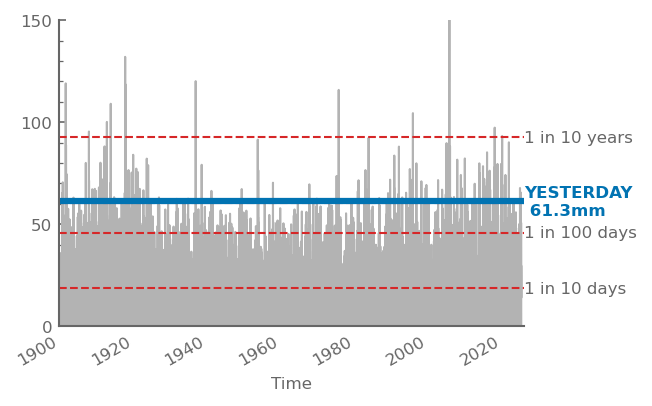

In [179]:
fig, ax = plt.subplots()
ds_bergen.plot(ax=ax, lw=1, color='.7')
ax.legend().remove()
ax.set_xlabel('Time')
ax.set_ylim(0,150)
ax.set_xlim(pd.to_datetime(['1900','2026']), None)
ax.yaxis.set_major_locator(plt.MultipleLocator(50))
ax.yaxis.set_minor_locator(plt.MultipleLocator(10))

texts = ['1 in 10 days', '1 in 100 days', '1 in a year', '1 in 10 years']
quantiles = ds_bergen.quantile([0.9,0.99,1-1/365, 1-1/365/10])
for k,quantile in enumerate(quantiles.values):
    if k!=2:
        ax.text(pd.to_datetime('2026'), quantile, texts[k], va='center')
    ax.axhline(quantile, color='tab:red', ls='--')
ax.axhline(61.3, lw=3)
ax.text(pd.to_datetime('2026'), 61, 'YESTERDAY\n 61.3mm', va='center', color='C0', weight='bold')

/tmp/ipykernel_162946/2676261878.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


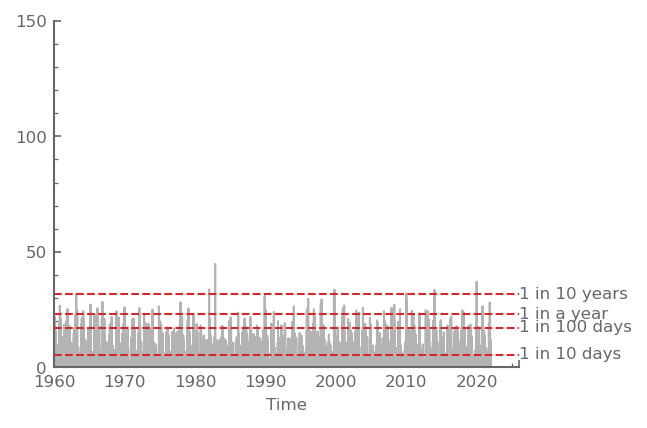

In [184]:
fig, ax = plt.subplots()
ds_spain.plot(ax=ax, lw=1, color='.7')
ax.legend().remove()
ax.set_xlabel('Time')
ax.set_ylim(0,150)
ax.set_xlim(pd.to_datetime(['1960','2026']), None)
ax.yaxis.set_major_locator(plt.MultipleLocator(50))
ax.yaxis.set_minor_locator(plt.MultipleLocator(10))

texts = ['1 in 10 days', '1 in 100 days', '1 in a year', '1 in 10 years']
quantiles = ds_spain.quantile([0.9,0.99,1-1/365, 1-1/365/10])
for k,quantile in enumerate(quantiles.values):
    if k!=7:
        ax.text(pd.to_datetime('2026'), quantile, texts[k], va='center')
    ax.axhline(quantile, color='tab:red', ls='--')
# ax.axhline(61.3, lw=3)
# ax.text(pd.to_datetime('2026'), 61, 'YESTERDAY\n 61.3mm', va='center', color='C0', weight='bold')

In [157]:
ds_bergen


,Nedbør (døgn)
Tid(norsk normaltid),
1861-01-01,0.0
1861-01-02,0.0
1861-01-03,0.0
1861-01-04,0.0
1861-01-05,0.0
...,...
2025-03-01,3.1
2025-03-02,6.2
2025-03-03,22.4


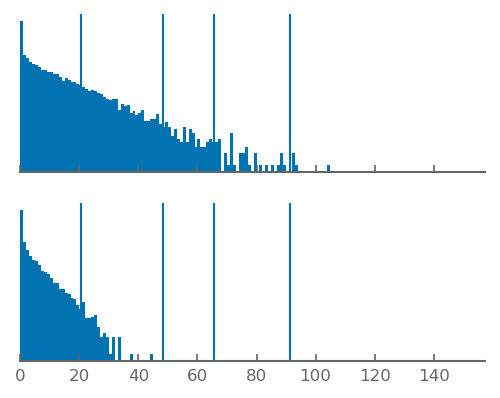

In [94]:
import seaborn as sns
fig, axs =plt.subplots(2,1, sharex=True, sharey=False)
df.Bergen.plot.hist(bins = np.arange(0,151,1), ax=axs[0])
df.SouthSpain.plot.hist(bins = np.arange(0,151,1), ax=axs[1])



for ax in axs:
    ax.set_xlim(0,None)
    ax.set_yscale('log')
    ax.tick_params(left=False, labelleft=False)
    ax.set_ylabel('')
    for quantile in quantiles.Bergen:
        ax.axvline(quantile)
sns.despine(left=True)